In [25]:
import numpy as np
import scipy as scipy
import scipy.special
import matplotlib.pyplot as plt
import time
import uncertainties as error
import pandas as pd

Problem 1

In [26]:
#This is my data input for the .txt files, may need to adjust the filepath
Data1=pd.read_csv('HW4_Data/data1.txt', names=['x', 'y', 'yerr'], delimiter=' ')
Data2=pd.read_csv('HW4_Data/data2.txt', names=['x', 'y', 'yerr'], delimiter=' ')

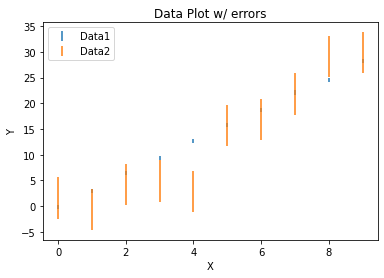

In [27]:
plt.errorbar(Data1['x'], Data1['y'], yerr=Data1['yerr'], label='Data1', linestyle='')
plt.errorbar(Data2['x'], Data2['y'], yerr=Data2['yerr'], label='Data2', linestyle='')
plt.legend()
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Data Plot w/ errors')
plt.show()

In [153]:
#Let's do the uniform distribution on what the slope can be
#p(parameter | data, model) = integral of p(data|model, parameter)p(parameter)
density=1001
mtest=np.linspace(0, 10, density)

def UniformPrior(mtest, start=0, stop=10):
    return(np.zeros(density)+1/len(mtest))

def GaussianPrior(mtest, mean, sigma, start=0, stop=10):
    return(1/(np.sqrt(2*np.pi)*sigma) * np.exp(-1/2 * (mtest-mean)**2/sigma**2))

def PDataGivenParam(Data, m, Prior):
    temp=[]
    for i in range(len(Data['y'])):
        temp.append(1/(np.sqrt(2*np.pi)*Data['yerr'][i]) * 
                    np.exp(-(Data['y'][i]-m*Data['x'][i])**2/(2*Data['yerr'][i]**2)))
    return(np.product(temp)) #this probably isn't normalized right whoops

Data1Uniform=[] #This is where we'll put our PDF's in
Data2Uniform=[]
Data1Gaussian=[]
Data2Gaussian=[]

mean=8 #Values for the gaussian prior
sigma=0.2
for i in range(len(mtest)):
    Data1Uniform.append(PDataGivenParam(Data1, mtest[i], UniformPrior(mtest)))
    Data2Uniform.append(PDataGivenParam(Data2, mtest[i], UniformPrior(mtest)))
    Data1Gaussian.append(PDataGivenParam(Data1, mtest[i], GaussianPrior(mtest, mean, sigma)))
    Data2Gaussian.append(PDataGivenParam(Data2, mtest[i], GaussianPrior(mtest, mean, sigma)))
    
Data1Uniform=Data1Uniform*UniformPrior(mtest)
Data2Uniform=Data2Uniform*UniformPrior(mtest)
Data1Gaussian=Data1Gaussian*GaussianPrior(mtest, mean, sigma)
Data2Gaussian=Data2Gaussian*GaussianPrior(mtest, mean, sigma)


Data1Uniform=Data1Uniform/-np.trapz(mtest, Data1Uniform)
Data2Uniform=Data2Uniform/-np.trapz(mtest, Data2Uniform)
Data1Gaussian=Data1Gaussian/-np.trapz(mtest, Data1Gaussian)
Data2Gaussian=Data2Gaussian/-np.trapz(mtest, Data2Gaussian)

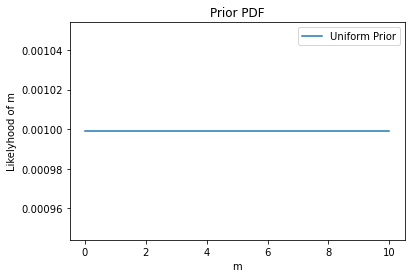

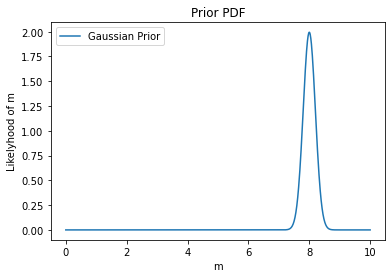

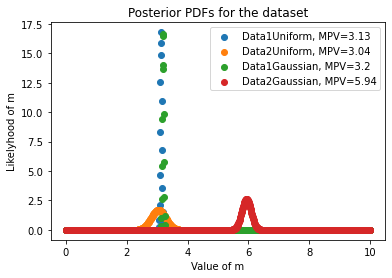

In [166]:
plt.plot(mtest, UniformPrior(mtest), linestyle='-', label='Uniform Prior')
plt.legend()
plt.title('Prior PDF')
plt.xlabel('m')
plt.ylabel('Likelyhood of m')
plt.show()
plt.plot(mtest, GaussianPrior(mtest, mean, sigma), linestyle='-', label='Gaussian Prior')
plt.legend()
plt.title('Prior PDF')
plt.xlabel('m')
plt.ylabel('Likelyhood of m')
plt.show()

plt.scatter(mtest, Data1Uniform, label='Data1Uniform, MPV='+str(mtest[np.argmax(Data1Uniform)]))
plt.scatter(mtest, Data2Uniform, label='Data2Uniform, MPV='+str(mtest[np.argmax(Data2Uniform)]))
plt.scatter(mtest, Data1Gaussian, label='Data1Gaussian, MPV='+str(mtest[np.argmax(Data1Gaussian)]))
plt.scatter(mtest, Data2Gaussian, label='Data2Gaussian, MPV='+str(mtest[np.argmax(Data2Gaussian)]))
plt.legend()
plt.title('Posterior PDFs for the dataset')
plt.xlabel('Value of m')
plt.ylabel('Likelyhood of m')
plt.show()

In [ ]:
#I think Data1 is just too good for it to really move the MPV

In [140]:
np.where()

array([1.10418967e-87, 1.64692801e-87, 2.45545416e-87, ...,
       7.97246508e-01, 7.97725000e-01, 7.97884561e-01])